# SaaS FinTech Product Funnel Analysis — Python Deep Dive
Loads the cleaned data (exported from MySQL after schema_and_load.sql's
cleaning steps) as CSVs, reproduces the key data-quality checks in
pandas, and builds a single analysis-ready dataframe for the
cohort/statistical/visualization work ahead.

In [1]:
import os
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## 1. Load cleaned tables from CSV

Export each table from MySQL Workbench after running schema_and_load.sql:
run `SELECT * FROM <table_name>;`, then click the Export icon above the
Result Grid and save as CSV. Repeat for all four tables and save them
together in one folder — update DATA_DIR below to point at it.

Exporting after cleaning (not the raw csv_raw/ files) matters here —
this notebook assumes duplicates are already removed, event_type
casing is already standardized, and stray cancelation_reason values
are already nulled out.

In [2]:
DATA_DIR = 'csv_cleaned'  # folder containing your exported CSVs

users = pd.read_csv("users_cleaned.csv", na_values=['NULL'])
campaigns = pd.read_csv("marketing_campaigns_cleaned.csv", na_values=['NULL'])
funnel_events = pd.read_csv("funnel_events_cleaned.csv", parse_dates=['event_timestamp'], na_values=['NULL'])
subscriptions = pd.read_csv("subscriptions_cleaned.csv", na_values=['NULL'])

users['signup_date'] = pd.to_datetime(users['signup_date'])

print(f'users:            {users.shape}')
print(f'marketing_campaigns: {campaigns.shape}')
print(f'funnel_events:     {funnel_events.shape}')
print(f'subscriptions:     {subscriptions.shape}')

users:            (8000, 9)
marketing_campaigns: (22, 6)
funnel_events:     (29508, 5)
subscriptions:     (1085, 9)


## 2. Anti-join / data-quality checks
Reproduces the checks already validated in schema_and_load.sql and
exploratory_queries.sql (see the Q1 note there on the subscriptions-table
ground-truth decision), now in pandas — confirms the
Python-side load matches what SQL already found before any analysis
builds on top of it.

In [3]:
# 2a. Orphaned funnel_events: user_id not present in users
orphaned_events = funnel_events[~funnel_events['user_id'].isin(users['user_id'])]
print(f'Orphaned funnel_events rows: {len(orphaned_events)}  (expected: 30)')
assert len(orphaned_events) == 30, (
    f'Expected 30 orphaned events, got {len(orphaned_events)} — likely a bad '
    f're-export (see the row-limit and literal-NULL issues from earlier).'
)

# 2b. Phantom subscriptions: users with a 'subscribed' event but no
#     matching row in the subscriptions table
subscribed_event_users = set(funnel_events.loc[funnel_events['event_type'] == 'subscribed', 'user_id'])
real_subscriber_users = set(subscriptions['user_id'])
phantom_subscriptions = subscribed_event_users - real_subscriber_users
print(f'Phantom subscribed-event users (no subscriptions row): {len(phantom_subscriptions)}  (expected: 21)')
assert len(phantom_subscriptions) == 21, (
    f'Expected 21 phantom subscriptions, got {len(phantom_subscriptions)} — '
    f'check the funnel_events / subscriptions exports match.'
)

# 2c. Users with zero funnel events at all (shouldn't exist — everyone
#     gets at least a signup event by construction)
users_with_no_events = set(users['user_id']) - set(funnel_events['user_id'])
print(f'Users with zero funnel events: {len(users_with_no_events)}  (expected: 0)')
assert len(users_with_no_events) == 0, (
    f'Found {len(users_with_no_events)} users with zero funnel events — '
    f'this should never happen by construction. Check the users/funnel_events exports.'
)

# 2d. Any remaining event_type casing inconsistencies (should be none —
#     already standardized in SQL Section 4)
print(f'Distinct event_type values: {sorted(funnel_events["event_type"].unique())}')

Orphaned funnel_events rows: 30  (expected: 30)
Phantom subscribed-event users (no subscriptions row): 21  (expected: 21)
Users with zero funnel events: 0  (expected: 0)
Distinct event_type values: ['bank_linked', 'email_verified', 'first_deposit', 'kyc_approved', 'kyc_submitted', 'plan_selected', 'signup', 'subscribed']


### Data quality summary
Consolidates the checks above into one reference table.

In [4]:
quality_summary = pd.DataFrame({
    'Check': [
        'Users',
        'Funnel events',
        'Orphaned events',
        'Phantom subscriptions',
        'Users without events',
    ],
    'Count': [
        len(users),
        len(funnel_events),
        len(orphaned_events),
        len(phantom_subscriptions),
        len(users_with_no_events),
    ],
})
quality_summary

,Check,Count
0,Users,8000
1,Funnel events,29508
2,Orphaned events,30
3,Phantom subscriptions,21
4,Users without events,0


## 3. Build the sequential funnel-stage flag per user
Same logic as exploratory_queries.sql Q1/Q2: a user's furthest stage is
only counted if every stage before it is also present — a handful of
users (see SQL Q1 note) have a stray 'subscribed' event with gaps before
it, and this excludes those gaps from the *stage-reach* signal without
dropping the rows themselves.

In [5]:
STAGE_ORDER = ['signup', 'email_verified', 'kyc_submitted', 'kyc_approved',
               'bank_linked', 'first_deposit', 'plan_selected', 'subscribed']
STAGE_RANK = {s: i for i, s in enumerate(STAGE_ORDER)}

# Orphaned events excluded — same as the SQL JOIN to users throughout
clean_events = funnel_events[funnel_events['user_id'].isin(users['user_id'])].copy()
clean_events['stage_rank'] = clean_events['event_type'].map(STAGE_RANK)

# earliest timestamp per (user, stage)
user_stage_times = (
    clean_events.groupby(['user_id', 'event_type'])['event_timestamp']
    .min()
    .reset_index()
)
user_stage_times['stage_rank'] = user_stage_times['event_type'].map(STAGE_RANK)


def sequential_max_stage(stage_ranks: set) -> int:
    """Highest stage rank reachable as an unbroken prefix from 0."""
    rank = -1
    while rank + 1 in stage_ranks:
        rank += 1
    return rank


stages_by_user = user_stage_times.groupby('user_id')['stage_rank'].apply(set)
sequential_stage_rank = stages_by_user.apply(sequential_max_stage)
sequential_stage_rank.name = 'sequential_max_stage_rank'

## 4. Build the master analysis dataframe
One row per user, matching the grain used throughout exploratory_queries.sql.
"Subscribed" is defined by the subscriptions table (ground truth), same
decision made for the SQL phase.

In [6]:
master = users.merge(sequential_stage_rank, on='user_id', how='left')
master['sequential_max_stage_rank'] = master['sequential_max_stage_rank'].fillna(-1).astype(int)
master['furthest_stage_reached'] = master['sequential_max_stage_rank'].map(
    lambda r: STAGE_ORDER[r] if r >= 0 else None
)

# subscription outcome (ground truth from subscriptions table, not the
# funnel_events flag — same decision as the SQL phase)
sub_cols = subscriptions[['user_id', 'plan_tier', 'mrr', 'status',
                           'cancellation_reason', 'start_date']].copy()
sub_cols = sub_cols.rename(columns={'start_date': 'subscription_start_date'})
master = master.merge(sub_cols, on='user_id', how='left')
master['is_subscriber'] = master['user_id'].isin(subscriptions['user_id'])

# time-to-convert (signup event to first subscribed event), restricted to
# real subscribers only — same restriction as exploratory_queries.sql Q3
signup_times = (
    clean_events.loc[clean_events['event_type'] == 'signup']
    .groupby('user_id')['event_timestamp'].min()
)
subscribed_times = (
    clean_events.loc[
        (clean_events['event_type'] == 'subscribed') &
        (clean_events['user_id'].isin(subscriptions['user_id']))
    ]
    .groupby('user_id')['event_timestamp'].min()
)
convert_time = (subscribed_times - signup_times).dropna()
# Excludes negative durations (subscribed_time before signup_time) — same
# pre-signup-timestamp data-quality issue flagged in schema_and_load.sql
# (the "events before signup_date" check), and the same filter the
# overall time-to-convert query in exploratory_queries.sql Q3 applies
# (WHERE subscribed_time >= signup_time). ~8 users affected.
convert_time = convert_time[convert_time >= pd.Timedelta(0)]
master = master.merge(
    convert_time.dt.total_seconds().div(86400).rename('days_to_convert'),
    on='user_id', how='left'
)

# signup cohort (month), for the cohort analysis ahead
master['signup_month'] = master['signup_date'].dt.to_period('M').astype(str)

print(master.shape)
master.head()

(8000, 19)


,user_id,signup_date,acquisition_channel,device_type,country,age,occupation,referral_source,marketing_campaign_id,sequential_max_stage_rank,furthest_stage_reached,plan_tier,mrr,status,cancellation_reason,subscription_start_date,is_subscriber,days_to_convert,signup_month
0,1000037,2024-03-06,affiliate,ios,India,48,Software Engineer,NaN,210268.0,0,signup,NaN,NaN,NaN,NaN,NaN,False,NaN,2024-03
1,1000917,2024-03-30,paid_search,android,United States,37,Marketing Manager,NaN,421879.0,1,email_verified,NaN,NaN,NaN,NaN,NaN,False,NaN,2024-03
2,1003196,2024-01-24,social,web,United States,31,Unemployed,NaN,378167.0,3,kyc_approved,NaN,NaN,NaN,NaN,NaN,False,NaN,2024-01
3,1004011,2024-12-08,organic,ios,Germany,38,Sales Rep,NaN,NaN,6,plan_selected,NaN,NaN,NaN,NaN,NaN,False,NaN,2024-12
4,1004138,2023-04-19,organic,web,Germany,26,Marketing Manager,NaN,NaN,7,subscribed,premium,24.99,canceled,poor_support,2023-04-21,True,12.366254,2023-04


## 5. Sanity check against known SQL results
These should match exploratory_queries.sql Q1 and the overall conversion
rate exactly — if they don't, something in the Python merge logic
disagrees with the SQL and needs to be reconciled before going further.

In [7]:
stage_reach_counts = (
    master['sequential_max_stage_rank']
    .apply(lambda r: list(range(r + 1)))
    .explode()
    .value_counts()
    .sort_index()
)
stage_reach_counts.index = stage_reach_counts.index.map(lambda r: STAGE_ORDER[int(r)])
print('Sequential stage-reach counts (compare to exploratory_queries.sql Q1):')
print(stage_reach_counts)
print()

Sequential stage-reach counts (compare to exploratory_queries.sql Q1):
sequential_max_stage_rank
signup            8000
email_verified    6004
kyc_submitted     4237
kyc_approved      3497
bank_linked       2711
first_deposit     2240
plan_selected     1677
subscribed        1088
Name: count, dtype: int64



The 'subscribed' row above is the pure event-log sequential count —
before swapping in the subscriptions table as ground truth (same
reconciliation documented in the SQL phase). Made explicit below rather
than left as a comment.

In [8]:
sequential_subscribed = stage_reach_counts.get('subscribed', 0)
ground_truth_subscribed = master['is_subscriber'].sum()
print(f'Sequential subscribed-event users: {sequential_subscribed:,}')
print(f'Ground-truth subscribers (subscriptions table): {ground_truth_subscribed:,}')
print(f'Event-log vs. subscription discrepancy: {sequential_subscribed - ground_truth_subscribed:,}')

conversion_rate = master['is_subscriber'].mean() * 100
print(f'\nOverall conversion rate (using ground truth): {conversion_rate:.2f}%  (expected: 13.56%)')
assert ground_truth_subscribed == 1085, (
    f'Expected 1,085 ground-truth subscribers, got {ground_truth_subscribed} — '
    f'check the subscriptions export.'
)
assert abs(conversion_rate - 13.56) < 0.01, (
    f'Expected 13.56% conversion, got {conversion_rate:.2f}% — check the users/subscriptions exports.'
)

Sequential subscribed-event users: 1,088
Ground-truth subscribers (subscriptions table): 1,085
Event-log vs. subscription discrepancy: 3

Overall conversion rate (using ground truth): 13.56%  (expected: 13.56%)


## 6. Cohort analysis
Groups users by signup month and tracks conversion and stage-reach
through the funnel — the piece SQL doesn't show well, since a single
point-in-time query can't reveal whether a channel or the funnel itself
is improving or degrading over time.

In [9]:
cohort_size = master.groupby('signup_month')['user_id'].count().rename('cohort_size')
cohort_conversion = (
    master.groupby('signup_month')['is_subscriber']
    .mean()
    .mul(100)
    .round(2)
    .rename('conversion_rate_pct')
)
cohort_summary = pd.concat([cohort_size, cohort_conversion], axis=1)
print('Cohort size and conversion rate by signup month:')
cohort_summary

Cohort size and conversion rate by signup month:


,cohort_size,conversion_rate_pct
signup_month,,
2023-01,20,10.00
2023-02,35,14.29
2023-03,84,5.95
2023-04,95,12.63
2023-05,123,12.20
2023-06,133,16.54
2023-07,185,14.05
2023-08,215,12.56
2023-09,255,15.69


In [10]:
# Stage-reach % within each cohort — shows whether drop-off patterns are
# consistent across cohorts or shifting over time
cohort_stage_pct = pd.crosstab(
    master['signup_month'],
    master['furthest_stage_reached'],
    normalize='index'
).mul(100).round(1)
# reorder columns to match funnel order (crosstab sorts alphabetically by default)
present_stages = [s for s in STAGE_ORDER if s in cohort_stage_pct.columns]
cohort_stage_pct = cohort_stage_pct[present_stages]
print('% of each cohort whose FURTHEST stage was X (not cumulative reach):')
cohort_stage_pct

% of each cohort whose FURTHEST stage was X (not cumulative reach):


furthest_stage_reached,signup,email_verified,kyc_submitted,kyc_approved,bank_linked,first_deposit,plan_selected,subscribed
signup_month,,,,,,,,
2023-01,15.0,25.0,10.0,5.0,20.0,15.0,0.0,10.0
2023-02,22.9,20.0,11.4,2.9,8.6,11.4,8.6,14.3
2023-03,27.4,28.6,10.7,11.9,4.8,4.8,6.0,6.0
2023-04,24.2,25.3,9.5,8.4,4.2,7.4,8.4,12.6
2023-05,29.3,21.1,8.9,8.1,4.9,8.1,7.3,12.2
2023-06,23.3,31.6,3.0,6.8,5.3,7.5,6.0,16.5
2023-07,24.3,18.4,5.4,8.1,8.1,7.0,14.1,14.6
2023-08,25.6,23.7,9.3,9.8,3.7,8.4,7.0,12.6
2023-09,22.4,22.7,9.4,11.8,5.9,5.1,7.1,15.7


In [11]:
# Median time-to-convert by cohort — are later cohorts converting faster
# or slower than earlier ones?
cohort_convert_time = (
    master.loc[master['is_subscriber'], ['signup_month', 'days_to_convert']]
    .groupby('signup_month')['days_to_convert']
    .median()
    .round(2)
    .rename('median_days_to_convert')
)
cohort_summary_full = cohort_summary.join(cohort_convert_time)
print('Cohort summary with median time-to-convert:')
cohort_summary_full

Cohort summary with median time-to-convert:


,cohort_size,conversion_rate_pct,median_days_to_convert
signup_month,,,
2023-01,20,10.00,11.44
2023-02,35,14.29,8.99
2023-03,84,5.95,10.98
2023-04,95,12.63,8.78
2023-05,123,12.20,9.13
2023-06,133,16.54,9.86
2023-07,185,14.05,10.23
2023-08,215,12.56,8.78
2023-09,255,15.69,9.24


## 7. Statistical testing
Confirms whether the channel/device conversion gaps found in
exploratory_queries.sql Q4/Q5 are statistically meaningful or could be
explained by chance, and whether time-to-convert genuinely differs by
channel.

In [12]:
from scipy import stats

In [13]:
def cramers_v(crosstab):
    """Cramér's V effect size for a chi-square test of association."""
    chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
    n = crosstab.to_numpy().sum()
    r, k = crosstab.shape
    v = np.sqrt((chi2 / n) / min(k - 1, r - 1))
    return chi2, p_val, dof, v


def cramers_v_label(v):
    # Cohen's small/medium/large thresholds for Cramér's V are keyed to
    # min(r-1, k-1) — NOT the chi-square test's own dof printed below
    # (which is (r-1)*(k-1)). Both tests here have a binary outcome
    # column (is_subscriber), so k-1=1 always, making min(r-1, k-1)=1
    # regardless of how many channel/device categories exist on the
    # other axis — verified directly against both crosstabs' shapes
    # rather than assumed.
    if v < 0.1:
        return 'negligible'
    elif v < 0.3:
        return 'small'
    elif v < 0.5:
        return 'medium'
    return 'large'

In [14]:
# Chi-square: is acquisition_channel associated with conversion?
channel_crosstab = pd.crosstab(master['acquisition_channel'], master['is_subscriber'])
chi2, p_val, dof, v = cramers_v(channel_crosstab)
print('Chi-square test: acquisition_channel vs. conversion')
print(channel_crosstab)
print(f"\nchi2 = {chi2:.2f}, p-value = {p_val:.2e}, dof = {dof}")
print(f"Cramér's V = {v:.3f} ({cramers_v_label(v)} effect)")
print('=> statistically significant association' if p_val < 0.05 else '=> no significant association')

Chi-square test: acquisition_channel vs. conversion
is_subscriber        False  True 
acquisition_channel              
affiliate             1510     52
organic               2141    588
paid_search           1602    147
referral               385    282
social                1277     16

chi2 = 964.34, p-value = 1.91e-207, dof = 4
Cramér's V = 0.347 (medium effect)
=> statistically significant association


In [15]:
# Chi-square: is device_type associated with conversion?
device_crosstab = pd.crosstab(master['device_type'], master['is_subscriber'])
chi2, p_val, dof, v = cramers_v(device_crosstab)
print('Chi-square test: device_type vs. conversion')
print(device_crosstab)
print(f"\nchi2 = {chi2:.2f}, p-value = {p_val:.2e}, dof = {dof}")
print(f"Cramér's V = {v:.3f} ({cramers_v_label(v)} effect)")
print('=> statistically significant association' if p_val < 0.05 else '=> no significant association')

Chi-square test: device_type vs. conversion
is_subscriber  False  True 
device_type                
android         1815    317
ios             2421    355
web             2679    413

chi2 = 4.63, p-value = 9.86e-02, dof = 2
Cramér's V = 0.024 (negligible effect)
=> no significant association


### One-way ANOVA: time-to-convert across channels
Includes eta-squared alongside the p-value — with thousands of users,
statistical significance and practical significance are different
claims, and eta-squared distinguishes them.

In [16]:
converted = master.loc[master['is_subscriber'] & master['days_to_convert'].notna()]
groups = [g['days_to_convert'].values for _, g in converted.groupby('acquisition_channel')]
f_stat, p_val = stats.f_oneway(*groups)

grand_mean = converted['days_to_convert'].mean()
ss_between = sum(
    len(g) * (g['days_to_convert'].mean() - grand_mean) ** 2
    for _, g in converted.groupby('acquisition_channel')
)
ss_total = ((converted['days_to_convert'] - grand_mean) ** 2).sum()
eta_squared = ss_between / ss_total

print('One-way ANOVA: days_to_convert across acquisition_channel (converted users only)')
print(converted.groupby('acquisition_channel')['days_to_convert'].agg(['count', 'mean', 'median']).round(2))
print(f'\nF-statistic = {f_stat:.2f}, p-value = {p_val:.4f}')
print(f'Eta-squared = {eta_squared:.4f}')
if p_val < 0.05:
    print('=> statistically significant difference detected between at least one channel pair')
else:
    print('=> no statistically significant difference detected across channels')
    print('   (absence of evidence is not evidence of absence — interpret alongside sample sizes and effect size)')

One-way ANOVA: days_to_convert across acquisition_channel (converted users only)
                     count  mean  median
acquisition_channel                     
affiliate               52  9.61    9.76
organic                584  9.62    9.49
paid_search            144  9.42    9.22
referral               281  9.40    8.93
social                  16  9.95   10.18

F-statistic = 0.48, p-value = 0.7523
Eta-squared = 0.0018
=> no statistically significant difference detected across channels
   (absence of evidence is not evidence of absence — interpret alongside sample sizes and effect size)


## 8. Visualizations
The three headline charts (funnel, channel conversion, cohort heatmap)
are also exported to `images/` for the README; the rest render inline
only, since they're more exploratory / supporting detail.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
os.makedirs('images', exist_ok=True)

### Funnel stage reach
Same sequential-prefix + subscriptions-table logic as Section 3/5 —
'subscribed' here is the corrected 1,085 figure, not the raw 1,088.

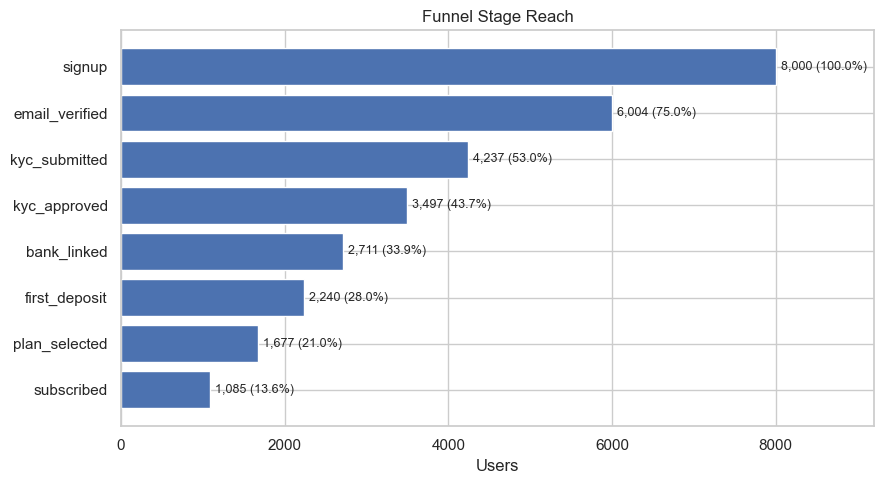

In [18]:
funnel_counts = stage_reach_counts.copy()
funnel_counts.loc['subscribed'] = int(master['is_subscriber'].sum())

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(funnel_counts.index[::-1], funnel_counts.values[::-1], color='#4C72B0')
for bar, val in zip(bars, funnel_counts.values[::-1]):
    pct = val / funnel_counts.iloc[0] * 100
    ax.text(bar.get_width() + 60, bar.get_y() + bar.get_height() / 2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Users')
ax.set_title('Funnel Stage Reach')
ax.set_xlim(0, funnel_counts.iloc[0] * 1.15)
plt.tight_layout()
plt.savefig('images/funnel_stage_reach.png', dpi=150)
plt.show()

### Conversion rate by acquisition channel

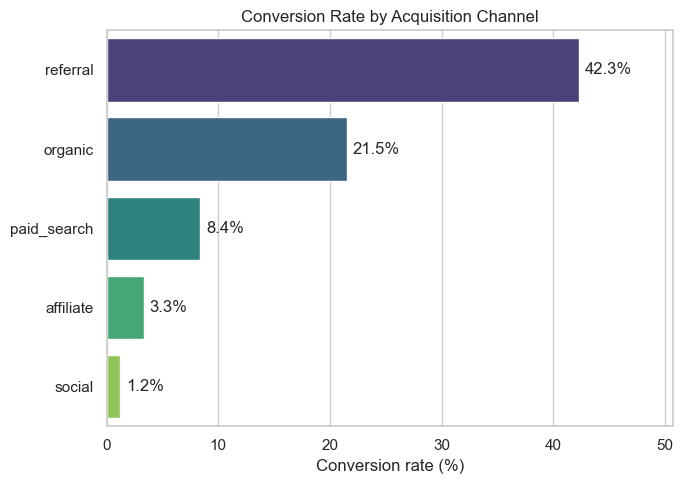

In [19]:
channel_conv = master.groupby('acquisition_channel')['is_subscriber'].mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=channel_conv.values, y=channel_conv.index, hue=channel_conv.index,
            palette='viridis', legend=False, ax=ax)
for i, v in enumerate(channel_conv.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
ax.set_xlabel('Conversion rate (%)')
ax.set_ylabel('')
ax.set_title('Conversion Rate by Acquisition Channel')
ax.set_xlim(0, channel_conv.max() * 1.2)
plt.tight_layout()
plt.savefig('images/conversion_by_channel.png', dpi=150)
plt.show()

### Time-to-convert distribution by channel
Visual companion to the ANOVA above (p=0.75, eta-squared shown there) —
no statistically significant difference was detected in time-to-convert
across channels, though this should be read alongside the very uneven
sample sizes per channel (labeled below) rather than as proof the
channels are truly identical.

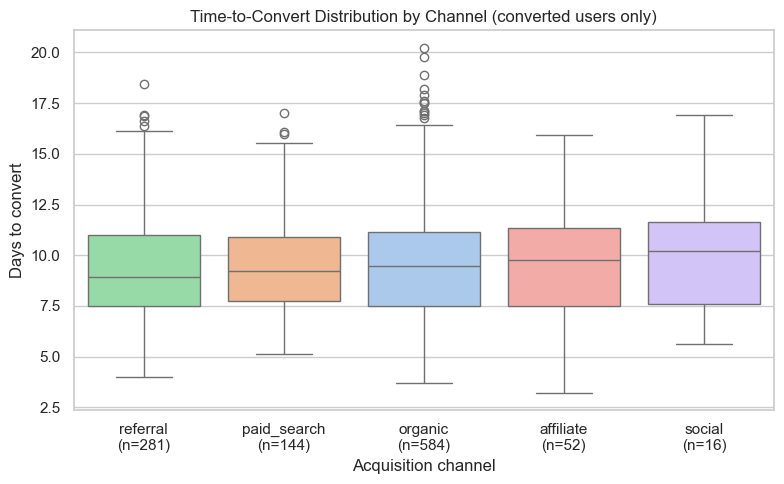

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
order = converted.groupby('acquisition_channel')['days_to_convert'].median().sort_values().index
channel_counts = converted['acquisition_channel'].value_counts()
labels = [f'{ch}\n(n={channel_counts[ch]:,})' for ch in order]

sns.boxplot(data=converted, x='acquisition_channel', y='days_to_convert', order=order,
            hue='acquisition_channel', palette='pastel', legend=False, ax=ax)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(labels)
ax.set_xlabel('Acquisition channel')
ax.set_ylabel('Days to convert')
ax.set_title('Time-to-Convert Distribution by Channel (converted users only)')
plt.tight_layout()
plt.show()

### Conversion rate by signup cohort
No clear trend up or down across the full 24-month span — the funnel
hasn't visibly improved or degraded over time.

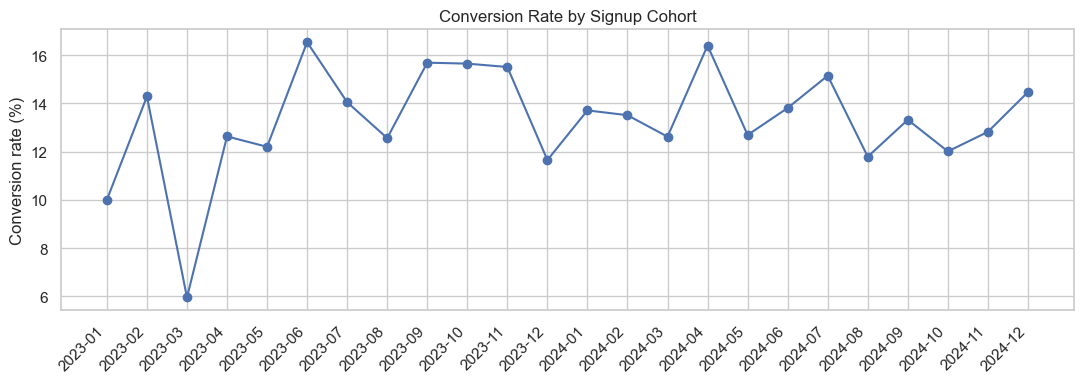

In [21]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(cohort_summary.index, cohort_summary['conversion_rate_pct'], marker='o', color='#4C72B0')
ax.set_xticks(range(len(cohort_summary.index)))
ax.set_xticklabels(cohort_summary.index, rotation=45, ha='right')
ax.set_ylabel('Conversion rate (%)')
ax.set_title('Conversion Rate by Signup Cohort')
plt.tight_layout()
plt.show()

### Cohort × furthest-stage-reached heatmap
Shows the drop-off pattern is consistent across cohorts, not shifting
over time (matches the flat cohort conversion trend above).

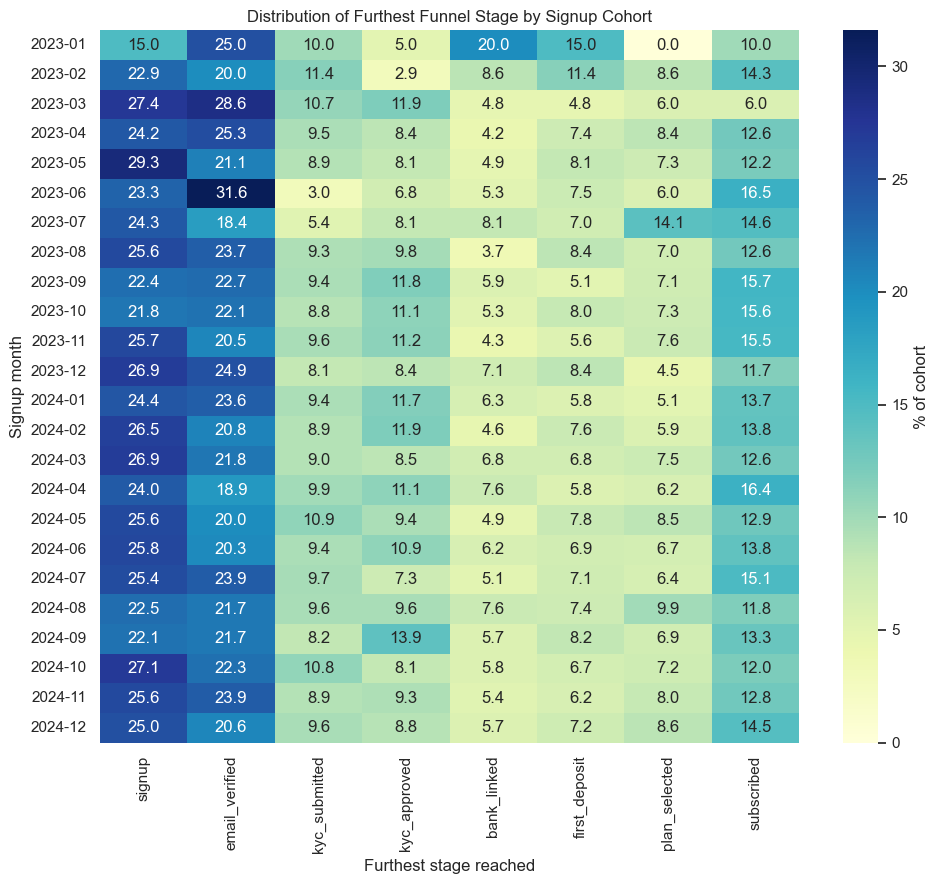

In [22]:
fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(cohort_stage_pct, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': '% of cohort'}, ax=ax)
ax.set_title('Distribution of Furthest Funnel Stage by Signup Cohort')
ax.set_xlabel('Furthest stage reached')
ax.set_ylabel('Signup month')
plt.tight_layout()
plt.savefig('images/cohort_stage_heatmap.png', dpi=150)
plt.show()

### Funnel conversion by acquisition channel
Connects acquisition and funnel progression directly — not just "which
channel converts best" (already shown above) but *where in the funnel*
each channel loses users. Cumulative reach per stage, same
sequential-prefix + subscriptions-table logic used throughout; ordered
by overall conversion rate to match the channel bar chart above.

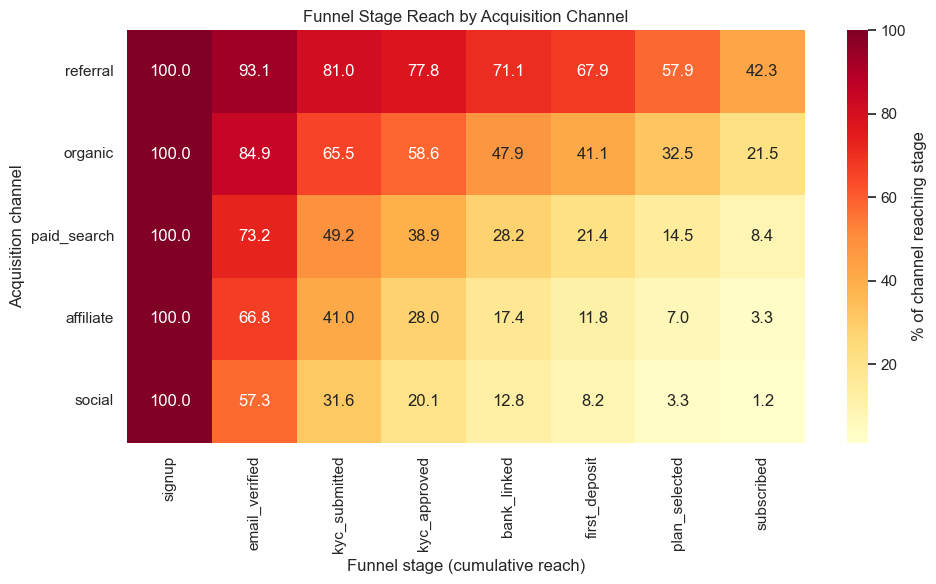

In [23]:
channel_order = channel_conv.index  # already sorted by conversion rate desc
channel_stage_pct = pd.DataFrame(index=channel_order, columns=STAGE_ORDER, dtype=float)

for ch in channel_order:
    ch_df = master.loc[master['acquisition_channel'] == ch]
    total = len(ch_df)
    for k, stage in enumerate(STAGE_ORDER):
        if stage == 'subscribed':
            reached = ch_df['is_subscriber'].sum()
        else:
            reached = (ch_df['sequential_max_stage_rank'] >= k).sum()
        channel_stage_pct.loc[ch, stage] = reached / total * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(channel_stage_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '% of channel reaching stage'}, ax=ax)
ax.set_title('Funnel Stage Reach by Acquisition Channel')
ax.set_xlabel('Funnel stage (cumulative reach)')
ax.set_ylabel('Acquisition channel')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('images/funnel_by_channel_heatmap.png', dpi=150)
plt.show()

## 9. Key Findings & Recommendations

In [24]:
# Quick current-MRR-by-channel calc (active subscriptions only, same
# definition as exploratory_queries.sql Q7) to ground the revenue finding
# below in an actual number rather than asserting it from memory.
current_mrr_by_channel = (
    master.loc[master['status'] == 'active']
    .groupby('acquisition_channel')['mrr']
    .sum()
    .round(2)
    .sort_values(ascending=False)
)
print('Current MRR by acquisition channel (active subscriptions only):')
current_mrr_by_channel

Current MRR by acquisition channel (active subscriptions only):


acquisition_channel
organic        4223.99
referral       1957.44
paid_search    1041.38
affiliate       291.83
social           99.94
Name: mrr, dtype: float64

In [25]:
# Plan x channel breakdown — more actionable than channel alone for the
# retention recommendation below, since it shows exactly which
# combination carries the most revenue rather than just which channel.
current_mrr_by_plan_channel = (
    master.loc[master['status'] == 'active']
    .groupby(['acquisition_channel', 'plan_tier'])['mrr']
    .sum()
    .round(2)
    .sort_values(ascending=False)
)
print('Current MRR by acquisition channel x plan tier (active subscriptions only):')
current_mrr_by_plan_channel

Current MRR by acquisition channel x plan tier (active subscriptions only):


acquisition_channel  plan_tier
organic              premium      2621.52
                     plus         1602.47
referral             premium      1242.07
                     plus          715.37
paid_search          premium       604.78
                     plus          436.60
affiliate            premium       149.96
                     plus          141.87
social               plus           54.96
                     premium        44.98
affiliate            free            0.00
organic              free            0.00
paid_search          free            0.00
referral             free            0.00
social               free            0.00
Name: mrr, dtype: float64

In [26]:
# Revenue-risk: canceled MRR by plan tier — connects the funnel/conversion
# story to actual revenue exposure from churn, not just a cancelation
# rate percentage.
canceled_mrr_by_plan = (
    master.loc[master['status'] == 'canceled']
    .groupby('plan_tier')['mrr']
    .agg(canceled_mrr='sum', canceled_customers='count')
    .round(2)
    .sort_values('canceled_mrr', ascending=False)
)
print('Revenue exposure from cancelations, by plan tier:')
canceled_mrr_by_plan

Revenue exposure from cancelations, by plan tier:


,canceled_mrr,canceled_customers
plan_tier,,
premium,837.19,38
plus,530.48,59
free,0.00,86


### Key Findings

1. **Funnel performance** — 13.56% of signups reach a real subscription
   (1,085 of 8,000). The largest single drop-off is `plan_selected` →
   `subscribed` (roughly 35%, exploratory_queries.sql Q2). The
   second-largest is `email_verified` → `kyc_submitted` (roughly 29%)
   — friction right at KYC *entry*, not KYC *processing*:
   `kyc_submitted` → `kyc_approved` itself has one of the lowest drop
   rates in the entire funnel (roughly 17%).
2. **Acquisition** — Referral has both the highest conversion rate
   (42.3%) and, per the chi-square test above, that association is
   statistically significant (p < 0.001, Cramér's V = 0.347, a medium
   effect) — a real, moderately-sized relationship, not just noise from
   a large sample. Organic contributes the highest subscriber volume.
3. **Conversion speed** — Users take a median of roughly 9-10 days to
   convert. No statistically significant difference in conversion time
   was detected across channels (ANOVA p=0.75, eta-squared shown
   above) — this is an absence of detected difference, not proof the
   channels are identical, and should be read alongside each channel's
   sample size.
4. **Cohort performance** — Conversion rates remained relatively stable
   (roughly 10-16%) across the 24 observed signup cohorts, with no
   obvious upward or downward trend in the observed period (a visual
   read of the chart above, not a formal time-series test).
5. **Revenue** — Organic carries the most active MRR today ($4,223.99),
   well ahead of referral ($1,957.44) — organic's larger subscriber
   volume wins out over referral's higher conversion *rate*. At the
   plan level, organic+premium is the single strongest combination
   ($2,621.52). On the risk side, premium cancellations cost roughly
   2.5x more per customer than plus cancellations ($22.03 vs. $8.99
   average, see the cancellation-risk table above) — plus has more
   cancelled customers (59 vs. 38), but premium's higher price point
   means each premium loss carries more revenue exposure.

### Recommendations

1. Focus product/checkout optimization on the `plan_selected` →
   `subscribed` transition — the single largest drop-off in the funnel.
2. Prioritize acquisition spend using both conversion rate *and* CAC
   (see exploratory_queries.sql Q6) — referral and organic outperform
   paid channels on both volume and efficiency.
3. Investigate KYC-entry friction specifically (`email_verified` →
   `kyc_submitted`), separately from the shared roughly-40-hour stall
   across every post-KYC stage (the average-time-between-stages part of
   Q3 in exploratory_queries.sql) — these look like two distinct
   problems, not one.
4. Continue monitoring cohort conversion over time — stable so far, but
   worth re-checking as channel mix or product changes.
5. Prioritize retention efforts around organic+premium specifically
   (the largest active-MRR combination) and premium cancellations
   generally, given their outsized per-customer revenue exposure
   relative to plus.

## 10. Export for Power BI
Exports the one-row-per-user `master` dataframe as the primary data
source for the Power BI dashboard — it already has the correct
sequential-prefix funnel logic and subscriptions-table ground truth
baked in, so Power BI doesn't need to re-derive any of that in DAX.
`marketing_campaigns.csv` (already exported in Phase 1/2) is the only
other table needed, for the CAC calculation, related on
`marketing_campaign_id` = `campaign_id`.

In [27]:
os.makedirs('power_bi_export', exist_ok=True)

pbi_export = master.copy()
# Power BI reads ISO dates cleanly; drop the intermediate rank column
# (furthest_stage_reached is the human-readable version Power BI should use)
pbi_export = pbi_export.drop(columns=['sequential_max_stage_rank'])
pbi_export.to_csv('power_bi_export/master.csv', index=False)

print(f'Exported power_bi_export/master.csv — {pbi_export.shape[0]:,} rows x {pbi_export.shape[1]} columns')
print(f'Columns: {list(pbi_export.columns)}')

Exported power_bi_export/master.csv — 8,000 rows x 18 columns
Columns: ['user_id', 'signup_date', 'acquisition_channel', 'device_type', 'country', 'age', 'occupation', 'referral_source', 'marketing_campaign_id', 'furthest_stage_reached', 'plan_tier', 'mrr', 'status', 'cancellation_reason', 'subscription_start_date', 'is_subscriber', 'days_to_convert', 'signup_month']


A second table for the funnel/stage-reach visuals specifically — the
cumulative sequential-prefix logic (Section 3 above) is genuinely hard
to replicate correctly in DAX, so it's pre-computed here per channel
and exported long-format, ready for Power BI's native Funnel visual to
consume directly without re-deriving any of that logic.

In [28]:
funnel_rows = []
for ch in list(channel_stage_pct.index) + ['All Channels']:
    if ch == 'All Channels':
        ch_df = master
    else:
        ch_df = master.loc[master['acquisition_channel'] == ch]
    total = len(ch_df)
    for k, stage in enumerate(STAGE_ORDER):
        if stage == 'subscribed':
            reached = ch_df['is_subscriber'].sum()
        else:
            reached = (ch_df['sequential_max_stage_rank'] >= k).sum()
        funnel_rows.append({
            'segment': ch,
            'stage': stage,
            'stage_order': k,
            'users_reached': int(reached),
            'total_segment_users': total,
            'pct_of_segment': round(reached / total * 100, 2),
        })

funnel_stage_summary = pd.DataFrame(funnel_rows)
funnel_stage_summary.to_csv('power_bi_export/funnel_stage_summary.csv', index=False)
print(f'Exported power_bi_export/funnel_stage_summary.csv — {funnel_stage_summary.shape[0]} rows')
funnel_stage_summary.head(10)

Exported power_bi_export/funnel_stage_summary.csv — 48 rows


,segment,stage,stage_order,users_reached,total_segment_users,pct_of_segment
0,referral,signup,0,667,667,100.00
1,referral,email_verified,1,621,667,93.10
2,referral,kyc_submitted,2,540,667,80.96
3,referral,kyc_approved,3,519,667,77.81
4,referral,bank_linked,4,474,667,71.06
5,referral,first_deposit,5,453,667,67.92
6,referral,plan_selected,6,386,667,57.87
7,referral,subscribed,7,282,667,42.28
8,organic,signup,0,2729,2729,100.00
9,organic,email_verified,1,2317,2729,84.90
